In [1]:
import scanpy as sc
import anndata
import numpy as np
import pandas as pd
import scipy as sci
import seaborn as sns

import datetime
import autogenes as ag

import matplotlib as mpl
import matplotlib.pyplot as plt

import scanpy as sc
import anndata as ad

import re

/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Impor

In [2]:
#select replicate indices and save their sum
def removeReplicas(adata):
    #find genes with a '.' in their name
    noreplica = adata.var.loc[~adata.var.index.str.contains("\\."),:].index
    print(adata[:,noreplica])
    replicas = adata.var.loc[adata.var.index.str.contains("\\."),:].index
    uniques = set()
    new_var_names = set()
    for x in replicas: 
        uniques.add(x.split(".")[0])
        new_var_names.add(x.split(".")[0])
    new_var_names.update(noreplica.tolist())
    adata_new = sc.AnnData(np.zeros((len(adata.obs_names),len(new_var_names))))
    adata_new.var_names = list(new_var_names)
    adata_new.obs_names = adata.obs_names
    adata_new[:,noreplica].X = adata[:,noreplica].X
    adata_new.obs = adata.obs
    for x in uniques:
        ind = adata.var.loc[adata.var.index.str.contains(x),:].index
        if(len(ind)!=1):
            adata_new[:,x].X = np.sum(adata[:,ind].X,axis=1)
        else:
            adata_new[:,x].X =  adata[:,ind[0]].X
    return adata_new

def normalize_proportions(data,copy):
    if copy==True:
        data_copy = data.copy()
    else:
        data_copy = data
    data_copy[data_copy < 0] = 0
    for raw in data_copy.index:
        sum = data_copy.loc[raw].sum()
        if sum!=0:
            data_copy.loc[raw] = np.divide(data_copy.loc[raw],sum)
        else:
            data_copy.loc[raw] = 0
    return data_copy

## Load 3173 bulk data

In [3]:
CFHV_DATA_DIR = '/home/trc891/projects/cyb/pubs/Cybulski_et_al_2025/data/cybulski_et_al_2025_GEO_sub/processed'
CFHV_DEMO_DIR = '/home/trc891/projects/cyb/pubs/Cybulski_et_al_2025/data/geo_archive'

cfhv_demo = pd.read_csv(f'{CFHV_DEMO_DIR}/cfhv_bulk_samplesheet_reduced.csv')
# tx2gene = pd.read_csv(f'{CFHV_DATA_DIR}/salmon_tx2gene.tsv', sep='\t', names=["TXNAME", "GENEID", "GENENAME"])

cfhv_ct_df = pd.read_csv(f'{CFHV_DATA_DIR}/bulk/cfhv_bulk.salmon.merged.gene_counts.reduced.tsv', sep=',', index_col=0)

cfhv_bulk_ds = sc.AnnData(X=cfhv_ct_df.T, obs=cfhv_demo.set_index('GEO_ID'))

/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
cfhv_ct_df

,CFHV_bulk_subj_001,CFHV_bulk_subj_003,CFHV_bulk_subj_004,CFHV_bulk_subj_011,CFHV_bulk_subj_012,CFHV_bulk_subj_015,CFHV_bulk_subj_045,CFHV_bulk_subj_046,CFHV_bulk_subj_047,CFHV_bulk_subj_048,CFHV_bulk_subj_049
gene_name,,,,,,,,,,,
TSPAN6,1528.0,2173.936,1272.000,3684.0,3496.000,1417.000,937.000,965.000,2226.000,818.000,2294.000
TNMD,0.0,0.000,2.000,0.0,0.000,2.000,0.000,1.000,0.000,6.000,1.000
DPM1,267.0,401.000,266.000,348.0,453.999,134.001,229.001,238.999,312.999,236.000,329.730
SCYL3,299.0,359.949,307.000,434.0,615.000,263.000,301.190,223.000,475.999,235.000,299.000
FIRRM,17.0,60.000,29.426,54.0,151.000,38.000,73.813,33.000,35.000,86.980,68.000
...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000310553,0.0,1.010,0.000,3.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ENSG00000310554,0.0,0.000,0.000,0.0,0.000,0.500,2.000,0.000,0.000,0.000,0.558
ENSG00000310555,0.0,0.000,0.000,0.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [5]:
cfhv_bulk_ds.var_names_make_unique()
cfhv_bulk_ds = removeReplicas(cfhv_bulk_ds)

/home/trc891/.conda/envs/cfn_final/lib/python3.10/site-packages/anndata/utils.py:264: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD115-1', 'SNORD115-2', 'SNORD115-3', 'SNORD115-4', 'SNORD115-5']
  warnings.warn(


View of AnnData object with n_obs × n_vars = 11 × 78922
    obs: 'RIN', 'Class', 'Sex', 'CFTRMod', 'HEMTStatus'


In [6]:
cfhv_bulk_proc = cfhv_bulk_ds.copy()
sc.pp.normalize_per_cell(cfhv_bulk_proc, counts_per_cell_after=1e4, copy=False)

## Load Alexandria Data

In [7]:
adata = sc.read_text(f'/home/trc891/projects/cyb/2022-CFnose/data/03CF_3173/shalek_2018/20180921_PolypScrape_cleaned_data.txt.gz', delimiter='\t').T
meta_data = pd.read_csv('/home/trc891/projects/cyb/2022-CFnose/data/03CF_3173/shalek_2018/np_alexandria_meta_with_sss.csv', sep=',', index_col=0)

/tmp/ipykernel_3991579/2519022687.py:2: DtypeWarning: Columns (6,10,11,16,17,33,35) have mixed types. Specify dtype option on import or set low_memory=False.
  meta_data = pd.read_csv('/home/trc891/projects/cyb/2022-CFnose/data/03CF_3173/shalek_2018/np_alexandria_meta_with_sss.csv', sep=',', index_col=0)


In [8]:
adata.X = np.expm1(adata.X)

In [9]:
meta_data = meta_data.drop('TYPE',axis=0)
meta_data = meta_data.loc[adata.obs_names,:]

for s in meta_data.columns.values:
    adata.obs[s] = meta_data[s].tolist()

In [10]:
adata_proc = adata.copy()

In [11]:
sc.pp.normalize_per_cell(adata_proc, counts_per_cell_after=1e4, copy=False)
adata_log = sc.pp.log1p(adata_proc, copy=True)

### Find HVGs

In [12]:
n_top_genes = 5000
sc.pp.highly_variable_genes(adata_log, flavor='seurat', n_top_genes=n_top_genes)

In [13]:
sc.tl.pca(adata_log)
adata_log.obsm['X_pca'] *= -1  # multiply by -1 to match Seurat


sc.pp.neighbors(adata_log, n_neighbors=30)
sc.tl.umap(adata_log)

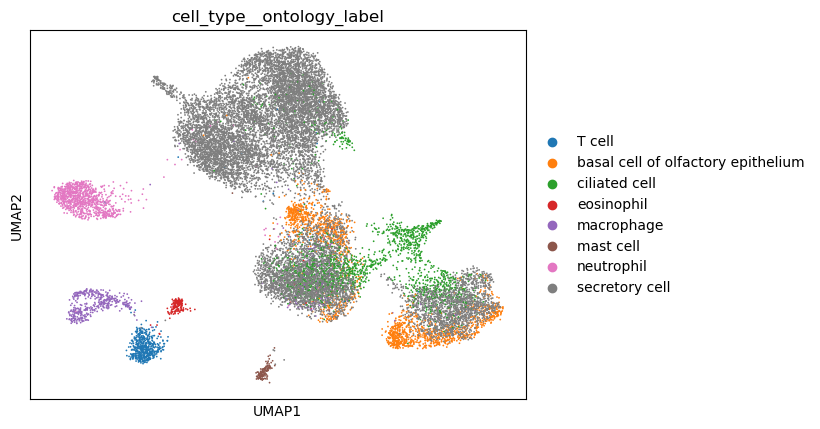

In [14]:
sc.pl.umap(adata_log,color='cell_type__ontology_label')

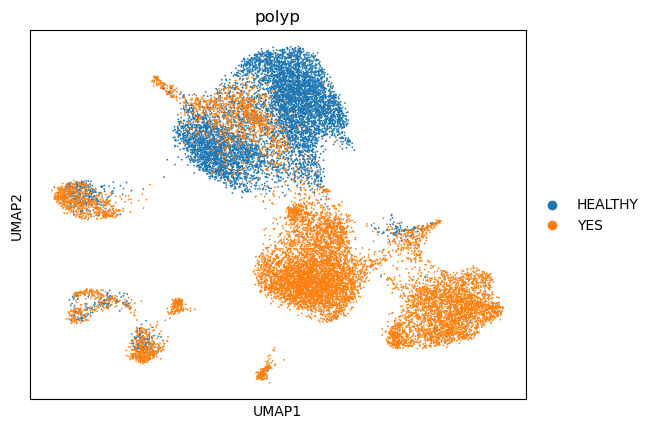

In [15]:
sc.pl.umap(adata_log, color='polyp')

In [16]:
shared_hv = np.intersect1d(adata_proc[:, adata_log.var_names[adata_log.var['highly_variable']==True]].var_names,
                           cfhv_bulk_ds.var_names
                          )

In [17]:
cfhv_adata_hv = adata_proc[:,shared_hv].copy()

## Train AutoGeneS

In [18]:
print(datetime.datetime.now())
time0 = datetime.datetime.now()

ngenes = 400 
ngen=5000
centroids = ag.init(cfhv_adata_hv, use_highly_variable=False, celltype_key='cell_type__ontology_label')
ag.optimize(ngen=ngen, seed=0, nfeatures=ngenes, mode='fixed', verbose=False)

print(datetime.datetime.now()-time0)

2026-03-10 14:18:52.722024
0:06:43.665645


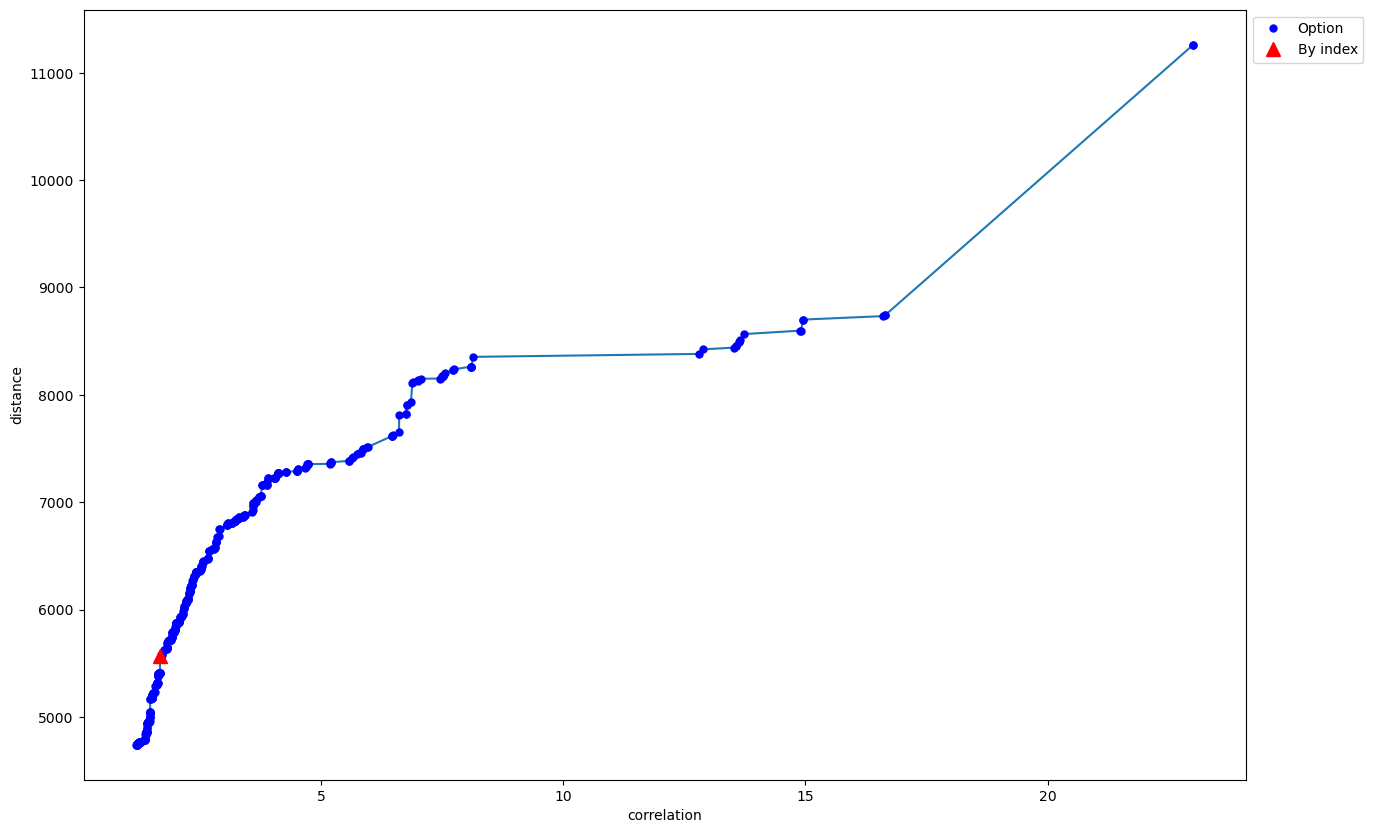

In [19]:
pareto = 155

ag.plot(index=pareto)
selection = ag.select(index=pareto)

centroids_sc_pareto = pd.DataFrame(centroids[:,selection].X.T,index=centroids[:,selection].var_names,columns=centroids[:,selection].obs_names)

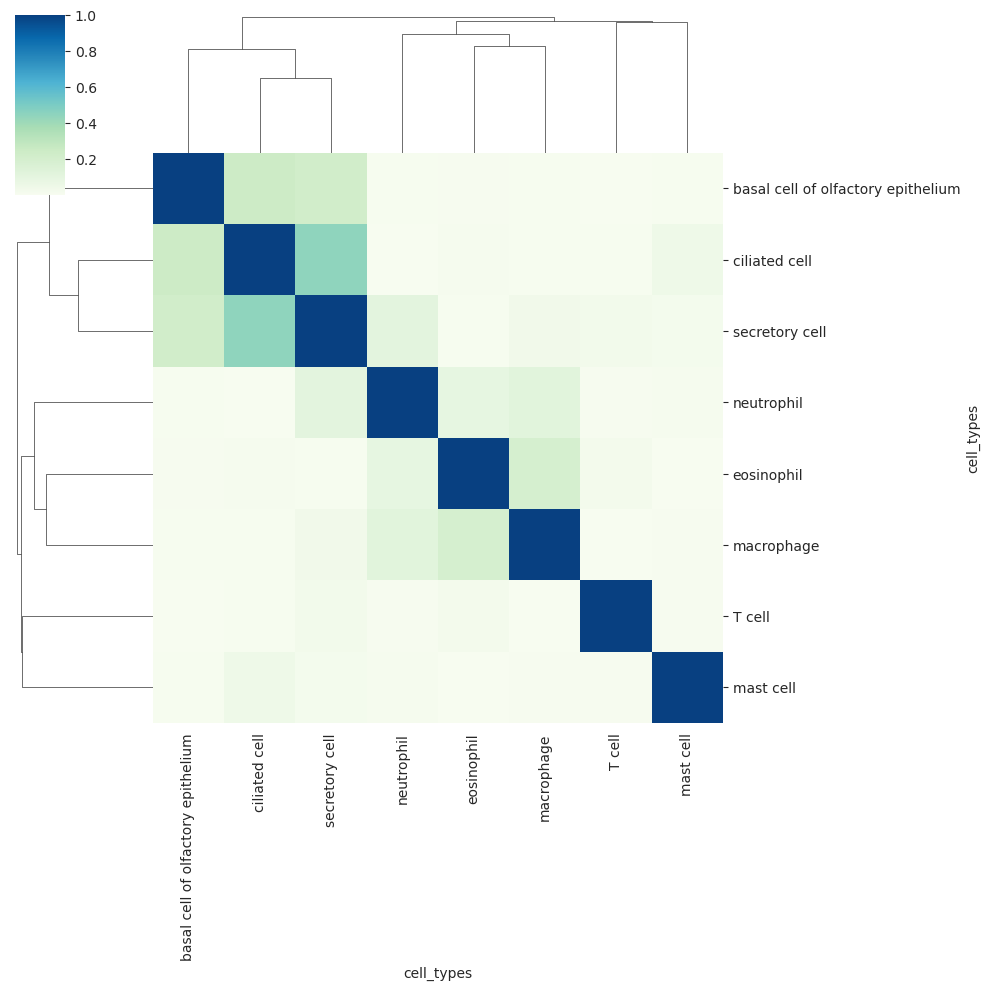

In [20]:
corr = pd.DataFrame(data = np.corrcoef(centroids_sc_pareto.T), columns = centroids_sc_pareto.columns, index = centroids_sc_pareto.columns)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
with sns.axes_style("white"):
    sns_plot =sns.clustermap(np.abs(corr),cmap=sns.color_palette("GnBu", 1000), robust=True)

## Deconvolve CF_3173 Bulk

In [21]:
cfhv_absent_bulk = shared_hv[~np.isin(shared_hv, cfhv_bulk_proc.var_names)]

In [22]:
cfhv_absent_zeros_bulk = np.zeros((cfhv_bulk_proc.shape[0], cfhv_absent_bulk.size))
cfhv_new_X_bulk = np.hstack([cfhv_bulk_proc.X, cfhv_absent_zeros_bulk])
cfhv_new_var_bulk = pd.concat([cfhv_bulk_proc.var, pd.DataFrame(index=cfhv_absent_bulk)])

cfhv_bulk_proc2 = sc.AnnData(cfhv_new_X_bulk, obs=cfhv_bulk_proc.obs, var=cfhv_new_var_bulk)
cfhv_bulk_hv = cfhv_bulk_proc2[:, shared_hv]

In [23]:
cfhv_coef_nnls_bulk = ag.deconvolve(cfhv_bulk_hv.X, model='nnls')

In [24]:
cfhv_proportions_nnls_bulk = pd.DataFrame(data=cfhv_coef_nnls_bulk.T,
                                          index=centroids_sc_pareto.columns,
                                          columns=cfhv_bulk_hv.obs_names)
cfhv_proportions_nnls_norm_bulk = normalize_proportions(cfhv_proportions_nnls_bulk.T, copy=True).T

cfhv_proportions_nnls_norm_bulk = cfhv_proportions_nnls_norm_bulk.set_index(cfhv_proportions_nnls_norm_bulk.index)
cfhv_proportions_nnls_norm_bulk = cfhv_proportions_nnls_norm_bulk.astype(float)

cfhv_proportions_bulk = cfhv_proportions_nnls_norm_bulk.copy()

In [25]:
cfhv_proportions_bulk

GEO_ID,CFHV_bulk_subj_001,CFHV_bulk_subj_003,CFHV_bulk_subj_004,CFHV_bulk_subj_011,CFHV_bulk_subj_012,CFHV_bulk_subj_015,CFHV_bulk_subj_045,CFHV_bulk_subj_046,CFHV_bulk_subj_047,CFHV_bulk_subj_048,CFHV_bulk_subj_049
cell_types,,,,,,,,,,,
T cell,0.006311,0.000000,0.007215,0.000000,0.014146,0.000000,0.013432,0.018883,0.001299,0.023270,0.000661
basal cell of olfactory epithelium,0.000000,0.000000,0.000000,0.009073,0.131993,0.181904,0.126254,0.000209,0.000000,0.218231,0.000000
ciliated cell,0.860667,0.154420,0.353144,0.810263,0.152783,0.088124,0.162116,0.294017,0.451358,0.233460,0.858150
eosinophil,0.028805,0.001909,0.011087,0.016865,0.035649,0.000000,0.044430,0.046600,0.020442,0.069314,0.019298
macrophage,0.096703,0.017532,0.014774,0.044770,0.194993,0.103608,0.098814,0.090328,0.038469,0.100686,0.047303
mast cell,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
neutrophil,0.007514,0.000000,0.000000,0.060359,0.290467,0.492518,0.271711,0.073330,0.034555,0.355039,0.005302
secretory cell,0.000000,0.826138,0.613779,0.058670,0.179969,0.133847,0.283243,0.476633,0.453877,0.000000,0.069285


In [26]:
row_order = """ciliated cell
secretory cell
basal cell of olfactory epithelium
T cell
mast cell
macrophage
eosinophil
neutrophil""".split("\n")

In [27]:
cfhv_sample_order_bulk = cfhv_proportions_bulk.columns

In [28]:
genotype_to_color = {
    "HV": 'tab:orange',
    "CF": 'tab:blue',
}

HEMT_to_color = {
    "Y": "xkcd:turquoise",
    "N": "xkcd:lavender",
    np.nan: "k"
}

genotype_colors_bulk = [genotype_to_color[g] for g in cfhv_bulk_proc.obs['Class']]
HEMT_colors_bulk = [HEMT_to_color[g] for g in cfhv_bulk_proc.obs['HEMTStatus']]

color_df = pd.DataFrame({"Class": genotype_colors_bulk,
                         "On HEMT": HEMT_colors_bulk,
                        },
                        index=cfhv_bulk_proc.obs.index
                       )

## Load sc data

In [29]:
SC_DATA_DIR = '../data/cfhv_sc'
SC_OUT_DIR = '../data/figs/cfhv_sc'

SC_SAMPLE_SHEET_PATH = f'{SC_DATA_DIR}/cfhv_sc_samplesheet.csv'
sc_sample_sheet = pd.read_csv(SC_SAMPLE_SHEET_PATH)

In [30]:
ds = ad.read_h5ad(f'{SC_DATA_DIR}/cfhv_sc_obj.h5ad')

In [31]:
batch_name = 'Sample'

# get counts for each sample, then pick a random column. Rename the column
ct_ds = ds.obs.groupby(['cell_type_annot', 'Class', batch_name], observed=True).count().Chemistry.reset_index()
ct_ds = ct_ds.rename(columns={'Chemistry': 'n_cells'})

# get total cell counts for each cluster
cluster_ct = ct_ds.groupby('cell_type_annot', observed=True).sum(numeric_only=True)
# get total cell counts for each subject
subj_ct = ct_ds.groupby(batch_name, observed=True).sum(numeric_only=True)

ct_ds['total_subj'] = 0
for i in subj_ct.itertuples(name=None):
    ct_ds.loc[ct_ds[batch_name] == i[0], 'total_subj'] = i[1]
    
ct_ds['cell_proportion_subj'] = ct_ds['n_cells'] / ct_ds['total_subj']

## Compare select proportions_bulk to ct_ds

In [32]:
sc_name_dict = {x.split('_')[3]: x for x in ct_ds['Sample'].unique()}
bulk_name_dict = {x.split('_')[3]: x for x in cfhv_proportions_bulk.columns}

common_ids = set(sc_name_dict.keys()).intersection(set(bulk_name_dict.keys()))

sc_name_dict = {k:v for k,v in sc_name_dict.items() if k in common_ids}
bulk_name_dict = {k:v for k,v in bulk_name_dict.items() if k in common_ids}

sc_name_dict_rev = {v:k for k,v in sc_name_dict.items()}
bulk_name_dict_rev = {v:k for k,v in bulk_name_dict.items()}

In [33]:
common_ids

{'001', '003', '004', '011', '015', '045', '046', '047', '048', '049'}

In [34]:
ct_ds_sel = ct_ds[ct_ds['Sample'].isin(sc_name_dict.values())]

In [35]:
ct_ds_sel_wide = ct_ds_sel.pivot(columns='Sample', index='cell_type_annot', values='cell_proportion_subj')
ct_ds_sel_wide = ct_ds_sel_wide.fillna(0)

In [36]:
prop_bulk_sel = cfhv_proportions_bulk[bulk_name_dict.values()]

In [37]:
bulk_ct_to_comp = ['basal cell of olfactory epithelium',
                   'ciliated cell',
                   'macrophage',
                   'secretory cell'
                  ]

sc_ct_to_comp = ['Basal',
                 'Multiciliated',
                 'Macrophages',
                 'Secretory'
                ]

ct_to_comp_dict = dict(zip(bulk_ct_to_comp, sc_ct_to_comp))

In [38]:
ct_limited = ct_ds_sel_wide.loc[sc_ct_to_comp, :]
ct_limited.columns = ct_limited.columns.map(sc_name_dict_rev)

ct_limited_norm = ct_limited / ct_limited.sum(axis=0)

ct_limited_norm = ct_limited_norm[ct_limited_norm.columns.sort_values()]
ct_limited_norm

Sample,001,003,004,011,015,045,046,047,048,049
cell_type_annot,,,,,,,,,,
Basal,0.051570,0.079720,0.067087,0.151550,0.230284,0.091362,0.383450,0.046789,0.492444,0.041505
Multiciliated,0.168161,0.132303,0.083790,0.109070,0.000000,0.048505,0.053613,0.137361,0.038222,0.293325
Macrophages,0.000000,0.003506,0.001095,0.008037,0.072555,0.020930,0.173077,0.002906,0.017778,0.003252
Secretory,0.780269,0.784472,0.848028,0.731343,0.697161,0.839203,0.389860,0.812945,0.451556,0.661917


In [39]:
sc_samp_order = ct_limited_norm.columns
sc_samp_class = ['CF'  if sc_sample_sheet.loc[sc_sample_sheet['GEO_ID_sc'] == f'CFHV_sc_subj_{x}', 'Class'].iloc[0] == 'CF'
                 else 'HV' for x in sc_samp_order]
sc_samp_colors = [genotype_to_color[g] for g in sc_samp_class]

sc_samp_color_df = pd.DataFrame({'Condition': sc_samp_colors},
                                index=ct_limited_norm.columns
                               )

sc_samp_class_df = pd.DataFrame({'Condition': sc_samp_colors,
                                 'Class': sc_samp_class
                                },
                                index=ct_limited_norm.columns
                               )

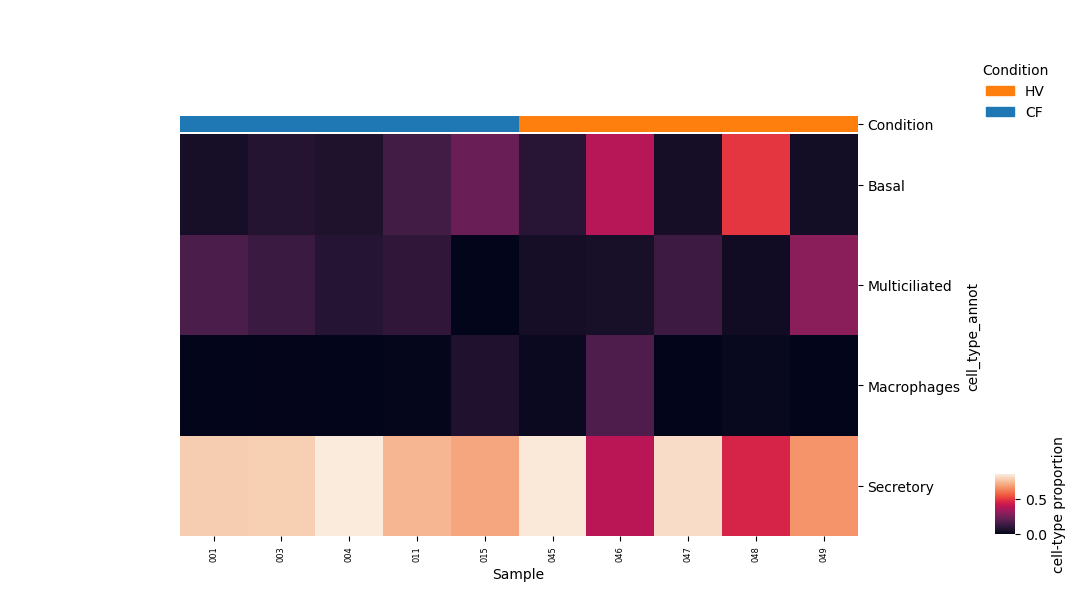

In [40]:
ax = sns.clustermap(
    ct_limited_norm, 
    col_cluster=False, 
    row_cluster=False, 
    col_colors=sc_samp_color_df,
    xticklabels=sc_samp_order,
    #xticklabels=False,
    figsize=(10, 6),
    cbar_pos=(1, 0.1, 0.02, 0.1),
    cbar_kws={'label': 'cell-type proportion'}
)

ax.ax_heatmap.tick_params(axis="x", rotation=90, labelsize=6)

ax.ax_col_dendrogram.legend(
    [mpl.patches.Patch(color=x) for x in genotype_to_color.values()],
    ["HV", "CF"],
    bbox_to_anchor=(1.3, 0.6),
    frameon=False,
    title="Condition"
)

#plt.savefig(f'{SC_OUT_DIR}/cfhv_schm_fig4a_new.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'{SC_OUT_DIR}/cfhv_schm_fig4a_new.svg', bbox_inches='tight')
plt.show()

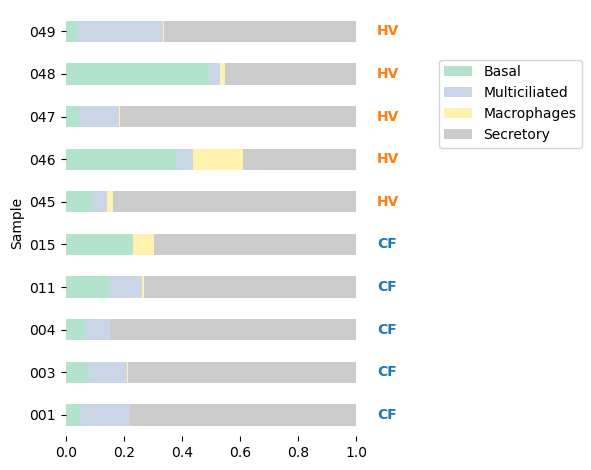

In [41]:
ax = ct_limited_norm.T.plot(
    kind='barh',
    stacked=True,
    colormap='Pastel2'
)

transform = ax.get_yaxis_transform()

for y_pos, label in zip(ax.get_yticks(), ax.get_yticklabels()):
    sample_name = label.get_text()
    sample_class = sc_samp_class_df['Class'].get(sample_name)
    sample_color = sc_samp_class_df['Condition'].get(sample_name)
    
    if sample_class in ['CF', 'HV']:
        ax.text(
            1.02,
            y_pos,
            sample_class,
            color=sample_color,
            fontweight='bold',
            ha='left',
            va='center',
            transform=transform
        )

ax.legend(bbox_to_anchor=(1.2, 0.9))
plt.tight_layout()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

#plt.savefig(f'{SC_OUT_DIR}/cfhv_schm_fig4a_new_revised.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'{SC_OUT_DIR}/cfhv_schm_fig4a_new_revised.svg', bbox_inches='tight')
plt.show()

In [42]:
bulk_limited_ct = prop_bulk_sel.loc[bulk_ct_to_comp, :]
bulk_limited_ct.columns = bulk_limited_ct.columns.map(bulk_name_dict_rev)
bulk_limited_ct.index = bulk_limited_ct.index.map(ct_to_comp_dict)

bulk_limited_ct_norm = bulk_limited_ct / bulk_limited_ct.sum(axis=0)

bulk_limited_ct_norm = bulk_limited_ct_norm[ct_limited_norm.columns.sort_values()]
bulk_limited_ct_norm

GEO_ID,001,003,004,011,015,045,046,047,048,049
cell_types,,,,,,,,,,
Basal,0.000000,0.000000,0.000000,0.009832,0.358444,0.188319,0.000243,0.000000,0.395076,0.000000
Multiciliated,0.898991,0.154716,0.359728,0.878071,0.173649,0.241810,0.341409,0.478284,0.422646,0.880390
Macrophages,0.101009,0.017566,0.015050,0.048517,0.204160,0.147389,0.104888,0.040763,0.182278,0.048529
Secretory,0.000000,0.827718,0.625223,0.063580,0.263747,0.422481,0.553461,0.480952,0.000000,0.071081


In [43]:
bulk_samp_order = bulk_limited_ct_norm.columns
bulk_samp_class = ['CF'  if cfhv_demo.loc[cfhv_demo['GEO_ID'] == f'CFHV_bulk_subj_{x}', 'Class'].iloc[0] == 'CF'
                   else 'HV' for x in sc_samp_order]
bulk_samp_colors = [genotype_to_color[g] for g in bulk_samp_class]

bulk_samp_color_df = pd.DataFrame({'Class': bulk_samp_colors},
                                index=bulk_limited_ct_norm.columns
                               )

bulk_samp_class_df = pd.DataFrame({'Condition': bulk_samp_colors,
                                   'Class': bulk_samp_class
                                  },
                                index=bulk_limited_ct_norm.columns
                               )

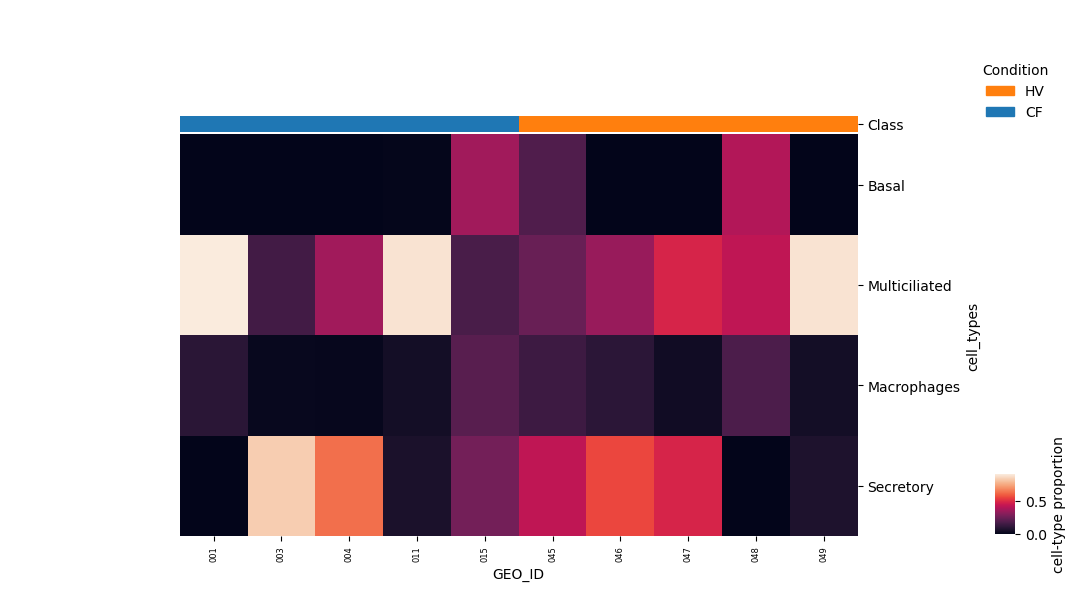

In [44]:
ax = sns.clustermap(
    bulk_limited_ct_norm, 
    col_cluster=False, 
    row_cluster=False, 
    col_colors=bulk_samp_color_df,
    xticklabels=bulk_samp_order,
    #xticklabels=False,
    figsize=(10, 6),
    cbar_pos=(1, 0.1, 0.02, 0.1),
    cbar_kws={'label': 'cell-type proportion'}
)

ax.ax_heatmap.tick_params(axis="x", rotation=90, labelsize=6)

ax.ax_col_dendrogram.legend(
    [mpl.patches.Patch(color=x) for x in genotype_to_color.values()],
    ["HV", "CF"],
    bbox_to_anchor=(1.3, 0.6),
    frameon=False,
    title="Condition"
)

#plt.savefig(f'{SC_OUT_DIR}/cfhv_bulkhm_fig4b_new.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'{SC_OUT_DIR}/cfhv_bulkhm_fig4b_new.svg', bbox_inches='tight')
plt.show()

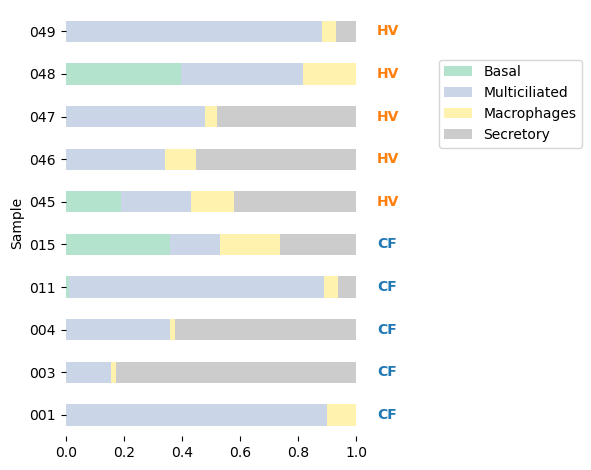

In [45]:
ax = bulk_limited_ct_norm.T.plot(
    kind='barh',
    stacked=True,
    colormap='Pastel2'
)

transform = ax.get_yaxis_transform()

for y_pos, label in zip(ax.get_yticks(), ax.get_yticklabels()):
    sample_name = label.get_text()
    sample_class = bulk_samp_class_df['Class'].get(sample_name)
    sample_color = bulk_samp_class_df['Condition'].get(sample_name)
    
    if sample_class in ['CF', 'HV']:
        ax.text(
            1.02,
            y_pos,
            sample_class,
            color=sample_color,
            fontweight='bold',
            ha='left',
            va='center',
            transform=transform
        )
        
plt.ylabel('Sample')

ax.legend(bbox_to_anchor=(1.2, 0.9))
plt.tight_layout()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

#plt.savefig(f'{SC_OUT_DIR}/cfhv_bulkhm_fig4b_new_revised.png', dpi=300, bbox_inches='tight')
#plt.savefig(f'{SC_OUT_DIR}/cfhv_bulkhm_fig4b_new_revised.svg', bbox_inches='tight')
plt.show()

In [46]:
bulk_sel_norm_long = pd.melt(bulk_limited_ct_norm.reset_index(names='cell_types'),
                        id_vars=['cell_types'],
                        value_name='proportion'
                       )
bulk_sel_norm_long.rename(columns={'GEO_ID': 'Sample'}, inplace=True)

sc_sel_norm_long = pd.melt(ct_limited_norm.reset_index(names='cell_types'),
                      id_vars=['cell_types'],
                      value_name='proportion'
                     )

joint_props_norm = pd.merge(sc_sel_norm_long, bulk_sel_norm_long, how='left',
                       left_on=['cell_types', 'Sample'],
                       right_on=['cell_types', 'Sample'],
                       suffixes=['_sc', '_bulk']
                      )
joint_props_norm

,cell_types,Sample,proportion_sc,proportion_bulk
0,Basal,001,0.051570,0.000000
1,Multiciliated,001,0.168161,0.898991
2,Macrophages,001,0.000000,0.101009
3,Secretory,001,0.780269,0.000000
4,Basal,003,0.079720,0.000000
5,Multiciliated,003,0.132303,0.154716
6,Macrophages,003,0.003506,0.017566
7,Secretory,003,0.784472,0.827718
8,Basal,004,0.067087,0.000000
9,Multiciliated,004,0.083790,0.359728


In [47]:
joint_props_norm_named = joint_props_norm.copy()
joint_props_norm_named.rename(columns={'cell_types': "Cell Type",
                                       'Sample': "Participant",
                                       'proportion_bulk': "Relative Proportion - Bulk",
                                       'proportion_sc': "Relative Proportion - Single Cell"
                              }, inplace=True
                             )

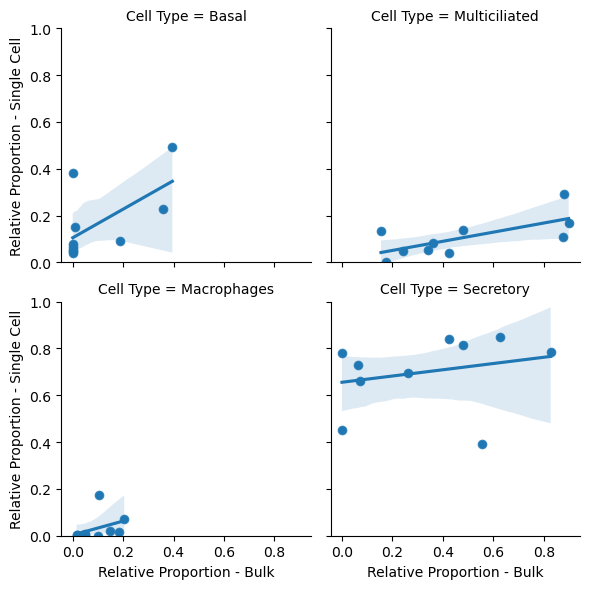

In [48]:
g = sns.FacetGrid(joint_props_norm_named, col='Cell Type', col_wrap=2)
g.map_dataframe(sns.scatterplot, x='Relative Proportion - Bulk', y='Relative Proportion - Single Cell')
g.map_dataframe(sns.regplot, x='Relative Proportion - Bulk', y='Relative Proportion - Single Cell')
g.set(ylim=(0, 1))

#plt.savefig(f'{SC_OUT_DIR}/cfhv_fig4c_new_revised.png', dpi=300)
#plt.savefig(f'{SC_OUT_DIR}/cfhv_fig4c_new_revised.svg')
plt.show()

In [49]:
for celltype in joint_props_norm['cell_types'].unique():
    temp_df = joint_props_norm[joint_props_norm['cell_types'] == celltype]
    res = sci.stats.spearmanr(temp_df['proportion_sc'],
                              temp_df['proportion_bulk'],
                              nan_policy='omit',
                              alternative='greater'
                             )
    print(f'{celltype}: {res.statistic}, p={res.pvalue}')

Basal: 0.8469257208241591, p=0.0009941843353395196
Multiciliated: 0.6363636363636362, p=0.023955863064987735
Macrophages: 0.6727272727272726, p=0.01652061127271885
Secretory: 0.41945482513924454, p=0.11377575511210765


In [50]:
for celltype in joint_props_norm['cell_types'].unique():
    temp_df = joint_props_norm[joint_props_norm['cell_types'] == celltype]
    res = sci.stats.pearsonr(temp_df['proportion_sc'],
                              temp_df['proportion_bulk'],
                              alternative='greater'
                             )
    print(f'{celltype}: {res.statistic}, p={res.pvalue}')

Basal: 0.6185821590465838, p=0.02829088470143814
Multiciliated: 0.6896496016965783, p=0.01366977410624051
Macrophages: 0.37084060659674195, p=0.14572134661957328
Secretory: 0.24616396515303482, p=0.24648870058168415
